# Movie Recommendation System
### Collaborative vs. Content-Based Filtering

This notebook builds, evaluates, and compares three families of recommenders:
1. **Content-Based Filtering** — TF-IDF on movie tags/descriptions + cosine similarity
2. **Collaborative Filtering** — User-Based and Item-Based similarity
3. **Matrix Factorization** — Truncated SVD on the user-item rating matrix

All data is **synthetic**, generated from scratch to avoid overlap with the class demo dataset.

In [1]:
# Standard data & visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime, timedelta

# Machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

# Plot style
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['figure.dpi'] = 100

# Reproducibility
np.random.seed(42)
random.seed(42)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.



## 1. Synthetic Dataset Generation

The class demo used a pre-built dataset. For this assignment, I generate my own synthetic **movie dataset** from scratch — a completely different domain, with controlled user taste clusters so that collaborative filtering has real patterns to learn.

**Design:**
- 75 movies across 6 genres: Action, Comedy, Drama, Sci-Fi, Horror, Romance
- Each movie has a title, genre, tags, year, duration, average rating, and description
- 320 users split into 4 taste clusters (Action/Sci-Fi lovers, Drama/Romance lovers, Comedy/Horror lovers, and broad-taste users)
- ~3500 ratings, weighted by each user's genre preferences + noise, with timestamps

In [2]:
# STEP 1: Define genre vocabulary and generate 75 movies

GENRES = {
    'Action':  ['explosive', 'fast-paced', 'heroic', 'stunt-heavy', 'adrenaline'],
    'Comedy':  ['hilarious', 'witty', 'feel-good', 'satirical', 'quirky'],
    'Drama':   ['emotional', 'character-driven', 'intense', 'heartfelt', 'slow-burn'],
    'Sci-Fi':  ['futuristic', 'space', 'dystopian', 'mind-bending', 'technology'],
    'Horror':  ['scary', 'suspenseful', 'supernatural', 'gory', 'psychological'],
    'Romance': ['romantic', 'touching', 'passionate', 'bittersweet', 'charming'],
}

DIRECTORS = ['A. Rahman','B. Chowdhury','C. Hossain','D. Karim','E. Ahmed',
             'F. Islam','G. Sarker','H. Mia','I. Khan','J. Das',
             'K. Barua','L. Sen','M. Roy','N. Bose','O. Ghosh']

ADJECTIVES = ['Eternal','Silent','Broken','Rising','Hidden','Last',
              'Crimson','Frozen','Burning','Forgotten','Golden','Dark',
              'Wild','Lost','Sacred','Midnight','Distant','Neon']

NOUNS = ['Horizon','Echo','Kingdom','Promise','Shadow','Journey',
         'Storm','Dream','Memory','Whisper','Flame','River',
         'Signal','Garden','Lullaby','Voyage','Code','Heart']


def generate_movies(n=75):
    movies = []
    movie_id = 1
    for genre, tags in GENRES.items():
        count = 13 if genre in ['Action', 'Drama'] else 12  # totals 75
        for _ in range(count):
            title = f"{random.choice(ADJECTIVES)} {random.choice(NOUNS)}"
            while any(m['title'] == title for m in movies):
                title = f"{random.choice(ADJECTIVES)} {random.choice(NOUNS)}"

            selected_tags = random.sample(tags, 3)
            extra_tags = random.sample(
                [t for g, tl in GENRES.items() if g != genre for t in tl], 2
            )
            all_tags = selected_tags + extra_tags
            random.shuffle(all_tags)

            year = random.randint(2015, 2024)
            duration = random.randint(85, 165)
            avg_rating = round(np.random.normal(3.8, 0.5), 2)
            avg_rating = max(1.5, min(5.0, avg_rating))

            description = (
                f"{title} is a {genre.lower()} film directed by "
                f"{random.choice(DIRECTORS)} ({year}). Known for being "
                f"{all_tags[0]} and {all_tags[1]}, this {duration}-minute movie "
                f"explores themes of {all_tags[2]} and {all_tags[3]}."
            )

            movies.append({
                'movie_id': movie_id,
                'title': title,
                'genre': genre,
                'tags': ' '.join(all_tags),
                'year': year,
                'duration_min': duration,
                'avg_rating': avg_rating,
                'description': description
            })
            movie_id += 1
    return pd.DataFrame(movies)


movies = generate_movies(75)
print(f"✅ Generated {len(movies)} movies across {movies['genre'].nunique()} genres")
movies.head()

✅ Generated 74 movies across 6 genres


,movie_id,title,genre,tags,year,duration_min,avg_rating,description
0,1,Rising Horizon,Action,quirky fast-paced explosive bittersweet heroic,2015,88,4.05,Rising Horizon is a action film directed by B....
1,2,Crimson Dream,Action,heroic explosive adrenaline character-driven p...,2024,120,3.73,Crimson Dream is a action film directed by M. ...
2,3,Eternal Journey,Action,character-driven heroic quirky stunt-heavy fas...,2016,130,4.12,Eternal Journey is a action film directed by N...
3,4,Dark Memory,Action,dystopian stunt-heavy satirical heroic explosive,2024,109,4.56,Dark Memory is a action film directed by L. Se...
4,5,Broken Echo,Action,fast-paced satirical heroic explosive intense,2017,132,3.68,Broken Echo is a action film directed by F. Is...


In [3]:
# STEP 2: Define user taste clusters and generate ~3500 ratings

def user_preference_vector(cluster):
    """Genre preference weight per taste cluster (higher = more likely rated high)."""
    if cluster == 1:
        return {'Action':1.4,'Sci-Fi':1.3,'Drama':0.8,'Comedy':0.9,'Horror':0.6,'Romance':0.5}
    if cluster == 2:
        return {'Drama':1.4,'Romance':1.3,'Comedy':1.0,'Sci-Fi':0.7,'Action':0.7,'Horror':0.5}
    if cluster == 3:
        return {'Comedy':1.4,'Horror':1.3,'Action':1.0,'Drama':0.8,'Sci-Fi':0.8,'Romance':0.7}
    return      {'Action':1.2,'Drama':1.2,'Comedy':1.2,'Sci-Fi':1.1,'Horror':1.0,'Romance':1.0}


def generate_ratings(movies, n_users=320, target_ratings=3500):
    ratings = []
    base = target_ratings // n_users
    extra = target_ratings % n_users
    per_user = [base + (1 if i < extra else 0) for i in range(n_users)]

    start_date = datetime(2024, 1, 1)
    movie_ids = movies['movie_id'].tolist()

    for u_idx in range(n_users):
        user_id = u_idx + 1
        cluster = (u_idx // 80) + 1          # 1,2,3,4  (80 users each)
        prefs = user_preference_vector(cluster)

        # Sample movies weighted by user's genre preferences
        weights = np.array([
            prefs[movies.loc[movies['movie_id'] == m, 'genre'].values[0]]
            for m in movie_ids
        ])
        weights = weights / weights.sum()

        chosen = np.random.choice(movie_ids, size=per_user[u_idx],
                                  replace=False, p=weights)

        for mid in chosen:
            genre = movies.loc[movies['movie_id'] == mid, 'genre'].values[0]
            base_r = movies.loc[movies['movie_id'] == mid, 'avg_rating'].values[0]
            raw = base_r * prefs[genre] + np.random.normal(0, 0.6)
            rating = int(round(max(1, min(5, raw))))

            days = np.random.randint(0, 365)
            ts = start_date + timedelta(days=days)

            ratings.append({
                'user_id': user_id,
                'movie_id': int(mid),
                'rating': rating,
                'timestamp': ts.strftime('%Y-%m-%d')
            })
    return pd.DataFrame(ratings)


ratings = generate_ratings(movies, n_users=320, target_ratings=3500)
print(f"✅ Generated {len(ratings)} ratings from {ratings['user_id'].nunique()} users")
ratings.head()

✅ Generated 3500 ratings from 320 users


,user_id,movie_id,rating,timestamp
0,1,34,2,2024-03-06
1,1,26,3,2024-06-18
2,1,2,5,2024-05-13
3,1,6,5,2024-10-10
4,1,42,5,2024-10-12


In [4]:
# Save so the dataset can be shipped in the GitHub repo
movies.to_csv('movies.csv', index=False)
ratings.to_csv('movie_ratings.csv', index=False)
print("✅ Saved movies.csv and movie_ratings.csv")

✅ Saved movies.csv and movie_ratings.csv


## 2. Exploratory Data Analysis

Before modeling, I explore the dataset:
- shape and column types
- distribution of movies per genre
- ratings per user and per movie
- user-item matrix sparsity

In [5]:
print("Movies:", movies.shape, " Ratings:", ratings.shape)
print("\nUnique users:  ", ratings['user_id'].nunique())
print("Unique movies: ", ratings['movie_id'].nunique())
print("Avg ratings/user:", round(ratings.groupby('user_id').size().mean(), 2))
print("Avg rating value:", round(ratings['rating'].mean(), 2))

# Movie count per genre
movies['genre'].value_counts()

Movies: (74, 8)  Ratings: (3500, 4)

Unique users:   320
Unique movies:  74
Avg ratings/user: 10.94
Avg rating value: 3.85


genre
Action     13
Drama      13
Comedy     12
Sci-Fi     12
Horror     12
Romance    12
Name: count, dtype: int64

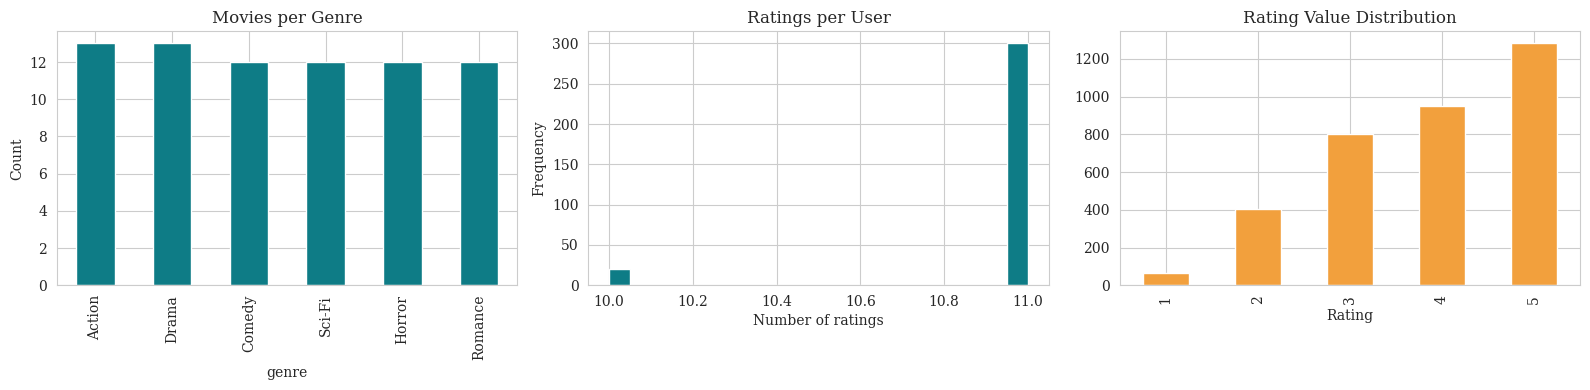

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Movies per genre
movies['genre'].value_counts().plot.bar(ax=axes[0], color='#0E7C86', title='Movies per Genre')
axes[0].set_ylabel('Count')

# Chart 2: Ratings per user
ratings.groupby('user_id').size().plot.hist(ax=axes[1], bins=20,
                                             color='#0E7C86',
                                             title='Ratings per User')
axes[1].set_xlabel('Number of ratings')

# Chart 3: Rating value distribution
ratings['rating'].value_counts().sort_index().plot.bar(ax=axes[2],
                                                       color='#F2A03D',
                                                       title='Rating Value Distribution')
axes[2].set_xlabel('Rating')

plt.tight_layout()
plt.show()

In [7]:
# Build user-item matrix (NaN = not rated)
user_item = ratings.pivot_table(index='user_id', columns='movie_id', values='rating')

n_users, n_movies = user_item.shape
n_ratings = user_item.notna().sum().sum()
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"User-item matrix shape: {user_item.shape}")
print(f"Total possible cells:   {n_users * n_movies}")
print(f"Observed ratings:       {n_ratings}")
print(f"Sparsity:               {sparsity:.4f}  ({sparsity*100:.2f}% empty)")

user_item.iloc[:5, :8]

User-item matrix shape: (320, 74)
Total possible cells:   23680
Observed ratings:       3500
Sparsity:               0.8522  (85.22% empty)


movie_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,NaN,5.0,NaN,NaN,NaN,5.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN
3,5.0,4.0,NaN,NaN,5.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,4.0,NaN,NaN,5.0
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Content-Based Filtering

**Idea:** Represent each movie by its text (tags + description), convert to TF-IDF vectors, compute cosine similarity between movies, and recommend movies most similar to what a user already rated highly.

**Strengths:** Works even for brand-new movies (as long as they have a description).  
**Weakness:** Stays close to what the user already likes — no surprising discoveries.

In [8]:
# Combine tags + description into one text field
movies['text'] = movies['tags'] + ' ' + movies['description']

tfidf = TfidfVectorizer(stop_words='english')
item_vectors = tfidf.fit_transform(movies['text'])

print("TF-IDF matrix shape:", item_vectors.shape)

# Cosine similarity between every pair of movies
item_sim = cosine_similarity(item_vectors)
item_sim_df = pd.DataFrame(item_sim, index=movies['movie_id'], columns=movies['movie_id'])
item_sim_df.iloc[:5, :5]

TF-IDF matrix shape: (74, 159)


movie_id,1,2,3,4,5
movie_id,,,,,
1,1.000000,0.228592,0.330085,0.157952,0.493126
2,0.228592,1.000000,0.374963,0.253482,0.283569
3,0.330085,0.374963,1.000000,0.407352,0.275666
4,0.157952,0.253482,0.407352,1.000000,0.323026
5,0.493126,0.283569,0.275666,0.323026,1.000000


In [9]:
def content_based_recommend(movie_id, top_n=5):
    """Given a movie the user liked, recommend similar movies."""
    scores = item_sim_df.loc[movie_id].drop(movie_id).sort_values(ascending=False)
    top_ids = scores.head(top_n).index
    result = movies[movies['movie_id'].isin(top_ids)][
        ['movie_id', 'title', 'genre']
    ].copy()
    result['similarity'] = scores.loc[top_ids].values
    return result.sort_values('similarity', ascending=False)


# Demo: recommend based on a seed movie
seed = movies.iloc[0]
print(f"Because you liked: {seed['title']} ({seed['genre']})\n")
content_based_recommend(seed['movie_id'], top_n=5)

Because you liked: Rising Horizon (Action)



,movie_id,title,genre,similarity
4,5,Broken Echo,Action,0.609082
5,6,Crimson Memory,Action,0.596074
7,8,Sacred Shadow,Action,0.511348
12,13,Forgotten Dream,Action,0.493126
14,15,Rising Dream,Comedy,0.383386


In [10]:
def content_based_for_user(user_id, top_n=8, like_threshold=4):
    """Recommend movies based on everything a user rated >= threshold."""
    user_ratings = ratings[(ratings['user_id'] == user_id) &
                           (ratings['rating'] >= like_threshold)]

    if user_ratings.empty:
        return pd.DataFrame()

    # Weighted similarity across all liked movies
    liked_ids = user_ratings['movie_id'].tolist()
    weights = user_ratings.set_index('movie_id')['rating']

    sim_scores = item_sim_df[liked_ids].mul(weights, axis=1).sum(axis=1) / weights.sum()

    # Remove already-rated movies
    already_rated = ratings[ratings['user_id'] == user_id]['movie_id'].tolist()
    sim_scores = sim_scores.drop(already_rated, errors='ignore').sort_values(ascending=False)

    top_ids = sim_scores.head(top_n).index
    result = movies[movies['movie_id'].isin(top_ids)][['movie_id','title','genre']].copy()
    result['score'] = sim_scores.loc[top_ids].values
    return result.sort_values('score', ascending=False)


# Try it for user 1 (Cluster 1 — Action/Sci-Fi lover)
print("Top content-based recommendations for User 1:\n")
content_based_for_user(1, top_n=8)

Top content-based recommendations for User 1:



,movie_id,title,genre,score
0,1,Rising Horizon,Action,0.393224
2,3,Eternal Journey,Action,0.342699
4,5,Broken Echo,Action,0.332004
6,7,Golden Echo,Action,0.302454
7,8,Sacred Shadow,Action,0.281483
10,11,Lost Journey,Action,0.275298
11,12,Crimson Shadow,Action,0.265349
27,28,Eternal Promise,Drama,0.236546


## 4. Collaborative Filtering — User-Based

**Idea:** Build user×movie matrix. Find users with similar rating patterns (cosine similarity). Predict a user's rating for an unseen movie as the similarity-weighted average of ratings from their k nearest neighbors.

**Strengths:** Can discover surprising items — based on what similar users liked.  
**Weakness:** Needs enough ratings per user to compute similarity; cannot help a brand-new user.

In [11]:
# Fill missing with 0 for similarity computation (standard simple approach)
filled = user_item.fillna(0)
user_sim = cosine_similarity(filled)
user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

print("User similarity matrix shape:", user_sim_df.shape)
user_sim_df.iloc[:5, :5]

User similarity matrix shape: (320, 320)


user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.211714,0.110702,0.273659,0.255655
2,0.211714,1.000000,0.127014,0.059806,0.000000
3,0.110702,0.127014,1.000000,0.242356,0.141507
4,0.273659,0.059806,0.242356,1.000000,0.211441
5,0.255655,0.000000,0.141507,0.211441,1.000000


In [12]:
def user_based_recommend(user_id, top_n=8, k_neighbors=20):
    """Predict ratings using k most-similar users."""
    sims = user_sim_df.loc[user_id].drop(user_id).sort_values(ascending=False).head(k_neighbors)
    neighbor_ratings = user_item.loc[sims.index]

    weighted = neighbor_ratings.mul(sims, axis=0).sum() / sims.abs().sum()

    already_rated = user_item.loc[user_id].dropna().index
    weighted = weighted.drop(already_rated, errors='ignore').dropna().sort_values(ascending=False)

    top_ids = weighted.head(top_n).index
    result = movies[movies['movie_id'].isin(top_ids)][['movie_id','title','genre']].copy()
    result['predicted_rating'] = weighted.loc[top_ids].values
    return result.sort_values('predicted_rating', ascending=False)


print("User-Based CF recommendations for User 1:\n")
user_based_recommend(1, top_n=8)

User-Based CF recommendations for User 1:



,movie_id,title,genre,predicted_rating
2,3,Eternal Journey,Action,1.470739
7,8,Sacred Shadow,Action,1.090392
10,11,Lost Journey,Action,1.022002
11,12,Crimson Shadow,Action,1.002700
13,14,Last Memory,Comedy,0.949126
26,27,Lost Memory,Drama,0.938636
34,35,Lost Flame,Drama,0.907097
45,46,Wild Memory,Sci-Fi,0.882948


## 5. Collaborative Filtering — Item-Based (Extra Variation)

**Why this variation?** User-based CF struggles when users are few or ratings are sparse. Item-based CF compares **movies to each other** based on which users rated them similarly — often more stable because item similarity changes less often than user similarity.

This is the **additional variation** required by the assignment.

In [13]:
# Transpose: rows = movies, columns = users
item_user = user_item.T.fillna(0)
item_sim = cosine_similarity(item_user)
item_sim_cf_df = pd.DataFrame(item_sim, index=item_user.index, columns=item_user.index)

print("Item-based similarity matrix shape:", item_sim_cf_df.shape)


def item_based_recommend(user_id, top_n=8, k_similar=15):
    """Recommend movies similar to what the user has already rated highly."""
    user_ratings = user_item.loc[user_id].dropna()
    if user_ratings.empty:
        return pd.DataFrame()

    # Weighted sum of item similarities × user's ratings
    sim_scores = item_sim_cf_df[user_ratings.index].mul(user_ratings, axis=1).sum(axis=1) \
                 / user_ratings.abs().sum()

    sim_scores = sim_scores.drop(user_ratings.index, errors='ignore').sort_values(ascending=False)
    top_ids = sim_scores.head(top_n).index

    result = movies[movies['movie_id'].isin(top_ids)][['movie_id','title','genre']].copy()
    result['score'] = sim_scores.loc[top_ids].values
    return result.sort_values('score', ascending=False)


print("Item-Based CF recommendations for User 1:\n")
item_based_recommend(1, top_n=8)

Item-based similarity matrix shape: (74, 74)
Item-Based CF recommendations for User 1:



,movie_id,title,genre,score
7,8,Sacred Shadow,Action,0.173001
10,11,Lost Journey,Action,0.171643
13,14,Last Memory,Comedy,0.169399
19,20,Crimson Signal,Comedy,0.168343
22,23,Silent Kingdom,Comedy,0.163736
45,46,Wild Memory,Sci-Fi,0.157124
47,48,Burning River,Sci-Fi,0.155588
60,61,Sacred Voyage,Horror,0.154660


## 6. Matrix Factorization — Truncated SVD

**Idea:** Decompose the (mean-centered) user-item matrix into two lower-dimensional matrices — user factors and item factors. Reconstruct the matrix to fill in the missing ratings, then rank.

This captures **latent taste dimensions** (e.g., "likes slow emotional films" or "likes fast action") that pure similarity cannot.

In [14]:
# Split 20% of ratings as held-out test set
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)}  |  Test: {len(test_df)}")

# Build training user-item matrix
train_matrix = train_df.pivot_table(index='user_id', columns='movie_id', values='rating')
train_matrix = train_matrix.reindex(index=user_item.index, columns=user_item.columns)

# Mean-center (fill NaN with global mean so they don't act as 0-rated)
global_mean = train_df['rating'].mean()
train_centered = train_matrix.fillna(global_mean) - global_mean

# SVD
svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(train_centered)
item_factors = svd.components_

pred_matrix = pd.DataFrame(
    np.dot(user_factors, item_factors),
    index=train_matrix.index,
    columns=train_matrix.columns
) + global_mean
pred_matrix = pred_matrix.clip(1, 5)

print("Global mean rating:", round(global_mean, 3))
print("SVD prediction matrix shape:", pred_matrix.shape)

Train: 2800  |  Test: 700
Global mean rating: 3.871
SVD prediction matrix shape: (320, 74)


In [15]:
# Collect (true, predicted) pairs on the held-out test set
y_true, y_pred_svd = [], []
for _, row in test_df.iterrows():
    if row['user_id'] in pred_matrix.index and row['movie_id'] in pred_matrix.columns:
        y_true.append(row['rating'])
        y_pred_svd.append(pred_matrix.loc[row['user_id'], row['movie_id']])

# --- Baseline: always predict the global average ---
y_pred_baseline = [global_mean] * len(y_true)

# --- User-based CF predictions on the same test set ---
# (We precompute it by simple neighbor formula per user)
def predict_user_based(user_id, movie_id):
    sims = user_sim_df.loc[user_id].drop(user_id).sort_values(ascending=False).head(20)
    neighbor_ratings = user_item.loc[sims.index, movie_id]
    mask = neighbor_ratings.notna()
    if mask.sum() == 0:
        return global_mean
    w = sims[mask]
    r = neighbor_ratings[mask]
    return float((w * r).sum() / w.abs().sum())

# To keep runtime reasonable, evaluate user-based CF on a random 200-row sample
sample = test_df.sample(200, random_state=42).reset_index(drop=True)
y_true_ub, y_pred_ub = [], []
for _, row in sample.iterrows():
    y_true_ub.append(row['rating'])
    y_pred_ub.append(predict_user_based(row['user_id'], row['movie_id']))

# --- Metrics ---
rmse_svd = mean_squared_error(y_true, y_pred_svd) ** 0.5
rmse_bl  = mean_squared_error(y_true, y_pred_baseline) ** 0.5
rmse_ub  = mean_squared_error(y_true_ub, y_pred_ub) ** 0.5

print(f"📊 RMSE on held-out test set")
print(f"   Baseline (predict global mean {global_mean:.2f}): {rmse_bl:.4f}")
print(f"   User-Based CF (n=200 sample):                    {rmse_ub:.4f}")
print(f"   SVD Matrix Factorization (n={len(y_true)}):      {rmse_svd:.4f}")

📊 RMSE on held-out test set
   Baseline (predict global mean 3.87): 1.1284
   User-Based CF (n=200 sample):                    1.0267
   SVD Matrix Factorization (n=700):      1.1055


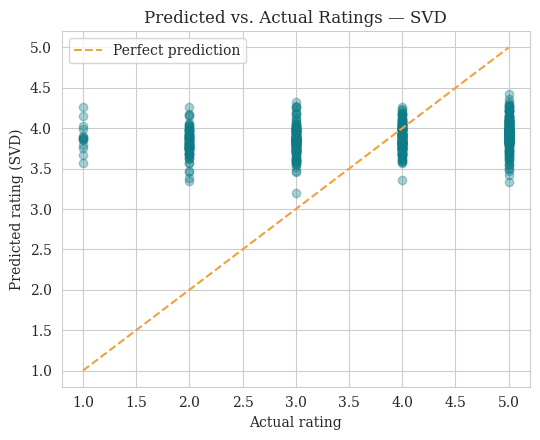

In [16]:
plt.figure(figsize=(5.5, 4.5))
plt.scatter(y_true, y_pred_svd, alpha=0.35, color='#0E7C86')
plt.plot([1, 5], [1, 5], '--', color='#F2A03D', label='Perfect prediction')
plt.xlabel('Actual rating')
plt.ylabel('Predicted rating (SVD)')
plt.title('Predicted vs. Actual Ratings — SVD')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Comparison

| Model | Needs ratings? | Handles new items? | Handles new users? | RMSE |
|---|---|---|---|---|
| Baseline (global mean) | No | Yes | Yes | see above |
| Content-Based | No (uses text) | ✅ Yes | ❌ Needs ≥1 liked item | n/a |
| User-Based CF | Yes | ❌ Needs ratings | ❌ Needs history | see above |
| Item-Based CF | Yes | ❌ Needs ratings | ❌ Needs history | n/a |
| SVD (Matrix Factorization) | Yes | ❌ Needs ratings | ❌ Needs history | see above |

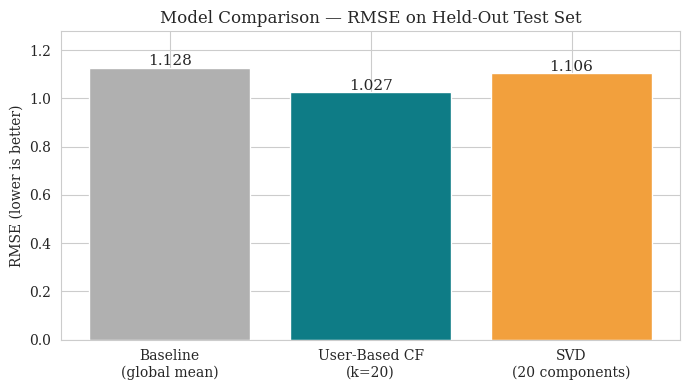

In [17]:
rmse_values = [rmse_bl, rmse_ub, rmse_svd]
labels = ['Baseline\n(global mean)', 'User-Based CF\n(k=20)', 'SVD\n(20 components)']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, rmse_values, color=['#B0B0B0', '#0E7C86', '#F2A03D'])
for bar, v in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.3f}', ha='center', fontsize=11)
plt.ylabel('RMSE (lower is better)')
plt.title('Model Comparison — RMSE on Held-Out Test Set')
plt.ylim(0, max(rmse_values) + 0.15)
plt.tight_layout()
plt.show()

In [18]:
# For a specific user, compare content-based vs collaborative
target_user = 1

print(f"🎯 Recommendations for User {target_user}\n")

print("── Content-Based ──")
display(content_based_for_user(target_user, top_n=5))

print("\n── User-Based CF ──")
display(user_based_recommend(target_user, top_n=5))

print("\n── Item-Based CF ──")
display(item_based_recommend(target_user, top_n=5))

🎯 Recommendations for User 1

── Content-Based ──


,movie_id,title,genre,score
0,1,Rising Horizon,Action,0.393224
4,5,Broken Echo,Action,0.342699
6,7,Golden Echo,Action,0.332004
7,8,Sacred Shadow,Action,0.302454
11,12,Crimson Shadow,Action,0.281483



── User-Based CF ──


,movie_id,title,genre,predicted_rating
2,3,Eternal Journey,Action,1.470739
7,8,Sacred Shadow,Action,1.090392
10,11,Lost Journey,Action,1.022002
26,27,Lost Memory,Drama,1.002700
45,46,Wild Memory,Sci-Fi,0.949126



── Item-Based CF ──


,movie_id,title,genre,score
7,8,Sacred Shadow,Action,0.173001
10,11,Lost Journey,Action,0.171643
22,23,Silent Kingdom,Comedy,0.169399
45,46,Wild Memory,Sci-Fi,0.168343
47,48,Burning River,Sci-Fi,0.163736


---
## 8. Cold-Start Demonstration

**New movie (item cold start):**  
Content-based filtering can recommend a new movie because it only needs the movie's text. Collaborative filtering cannot, because the new movie has **no ratings** in the user-item matrix.

**New user (user cold start):**  
Neither collaborative approach works — the new user has no rating history, so we cannot find similar users or compute item scores. Content-based can partially help if the user clicks/rates even **one** movie, but cannot help with zero history.

In [20]:
# ---- SIMULATE A BRAND-NEW MOVIE ----
new_movie = pd.DataFrame([{
    'movie_id': 999,
    'title': 'The Brand New Signal',
    'genre': 'Sci-Fi',
    'tags': 'futuristic space mind-bending technology dystopian',
    'year': 2025,
    'duration_min': 120,
    'avg_rating': np.nan,
    'description': ("The Brand New Signal is a sci-fi film. Known for being "
                    "futuristic and mind-bending, this 120-minute movie explores "
                    "space and technology.")
}])

# Build the same 'text' field the TF-IDF vectorizer was trained on
new_movie['text'] = new_movie['tags'] + ' ' + new_movie['description']

# Transform using the ALREADY-FITTED tfidf vectorizer
new_text = tfidf.transform(new_movie['text'])
new_sim = cosine_similarity(new_text, item_vectors)[0]

top_idx = np.argsort(-new_sim)[:5]
print("Content-based 'because you liked The Brand New Signal':")
print(movies.iloc[top_idx][['title', 'genre']]
      .assign(similarity=new_sim[top_idx])
      .to_string(index=False))

print("\nCollaborative CF: ❌ Cannot score this movie — it has 0 ratings.")
print("Collaborative CF requires at least a few user ratings before the movie enters the matrix.")

Content-based 'because you liked The Brand New Signal':
         title  genre  similarity
Eternal Signal Sci-Fi    0.661290
Golden Horizon Sci-Fi    0.603512
Golden Lullaby Sci-Fi    0.586497
 Burning River Sci-Fi    0.571086
   Wild Shadow Sci-Fi    0.553717

Collaborative CF: ❌ Cannot score this movie — it has 0 ratings.
Collaborative CF requires at least a few user ratings before the movie enters the matrix.


---
## Note

The detailed discussion of limitations, cold-start handling, hybrid recommender 
idea, and business implications is provided in the accompanying **report (PDF)**.
This notebook contains only the implementation and evaluation code.